<a href="https://colab.research.google.com/github/HongYeonLee/Artificial-Intelligence/blob/main/Final_Model_SEResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tiny-ImageNet-200 — Final Model (SE-ResNet-Tiny)
**Vision Model Leaderboard / 2026-1 Artificial Intelligence (Ewha)**

From-scratch CNN for Tiny-ImageNet (64x64, 200 classes). Single TorchScript module, < 5M parameters.

**Pipeline:** data -> augmentation (RandAugment + RandomErasing + MixUp/CutMix) -> SE-ResNet (~4.6M params) -> SGD + warmup-cosine + label smoothing + EMA -> TorchScript export with baked horizontal-flip TTA.

Run cells top-to-bottom on a Colab GPU runtime (T4 or better).

In [2]:
# === [Colab] Mount Google Drive and unzip the dataset ===
# Put student_data.zip in your Drive (e.g. MyDrive/student_data.zip).
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/data', exist_ok=True)
if not os.path.exists('/content/data/student_data/train'):
    !unzip -q "/content/drive/MyDrive/student_data.zip" -d "/content/data"
print('Data ready:', os.path.exists('/content/data/student_data/train'))

Mounted at /content/drive
Data ready: True


In [3]:
# === Imports, reproducibility, config ===
import os, time, math, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)

CFG = dict(
    data_root   = '/content/data/student_data',
    num_classes = 200,
    batch_size  = 128,
    epochs      = 120,        # 100-150 recommended; lower if time-limited
    warmup_ep   = 5,
    base_lr     = 0.1,        # SGD; scaled for batch 128
    weight_decay= 5e-4,
    momentum    = 0.9,
    label_smooth= 0.1,
    mixup_alpha = 0.2,
    cutmix_alpha= 1.0,
    aug_prob    = 0.5,        # prob. of applying mixup/cutmix per batch
    ema_decay   = 0.999,
    re_prob     = 0.25,       # random erasing prob
    num_workers = 8,
    ckpt        = 'best_ema.pth',
    out_pt      = 'final_model.pt',
)
MEAN = [0.4802, 0.4481, 0.3975]   # Tiny-ImageNet train statistics
STD  = [0.2770, 0.2691, 0.2821]
print(CFG)

PyTorch 2.11.0+cu128 | device: cuda
{'data_root': '/content/data/student_data', 'num_classes': 200, 'batch_size': 128, 'epochs': 120, 'warmup_ep': 5, 'base_lr': 0.1, 'weight_decay': 0.0005, 'momentum': 0.9, 'label_smooth': 0.1, 'mixup_alpha': 0.2, 'cutmix_alpha': 1.0, 'aug_prob': 0.5, 'ema_decay': 0.999, 're_prob': 0.25, 'num_workers': 8, 'ckpt': 'best_ema.pth', 'out_pt': 'final_model.pt'}


In [4]:
# === Datasets, augmentation, dataloaders ===
normalize = T.Normalize(MEAN, STD)

train_transform = T.Compose([
    T.RandomCrop(64, padding=8, padding_mode='reflect'),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    normalize,
    T.RandomErasing(p=CFG['re_prob'], scale=(0.02, 0.25), ratio=(0.3, 3.3)),
])
val_transform = T.Compose([T.ToTensor(), normalize])

class PublicValDataset(Dataset):
    """public_val/: images/ + labels.txt (lines: '<img_name> <wnid-or-idx>')."""
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir, self.transform = root_dir, transform
        self.items = []
        with open(os.path.join(root_dir, 'labels.txt'), 'r', encoding='utf-8') as f:
            for line in f:
                p = line.strip().split()
                if not p: continue
                name, lab = p[0], p[1]
                label = int(lab) if lab.isdigit() else class_to_idx[lab]
                self.items.append((name, label))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        name, label = self.items[i]
        img = Image.open(os.path.join(self.root_dir, 'images', name)).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

train_dir = os.path.join(CFG['data_root'], 'train')
val_dir   = os.path.join(CFG['data_root'], 'public_val')
train_set = ImageFolder(train_dir, transform=train_transform)
val_set   = PublicValDataset(val_dir, train_set.class_to_idx, transform=val_transform)

train_loader = DataLoader(train_set, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=256, shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
print(f'train: {len(train_set)} imgs / {len(train_set.classes)} classes | val: {len(val_set)} imgs')

train: 100000 imgs / 200 classes | val: 5000 imgs


In [5]:
# === MixUp / CutMix (batch-level) ===
def rand_bbox(W, H, lam):
    cut = math.sqrt(1. - lam)
    cw, ch = int(W * cut), int(H * cut)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, y1 = np.clip(cx - cw // 2, 0, W), np.clip(cy - ch // 2, 0, H)
    x2, y2 = np.clip(cx + cw // 2, 0, W), np.clip(cy + ch // 2, 0, H)
    return x1, y1, x2, y2

def mix_batch(x, y, cfg):
    """Returns mixed x, (y_a, y_b, lam). Randomly picks mixup or cutmix."""
    if np.random.rand() > cfg['aug_prob']:
        return x, (y, y, 1.0)
    idx = torch.randperm(x.size(0), device=x.device)
    if np.random.rand() < 0.5:                       # MixUp
        lam = float(np.random.beta(cfg['mixup_alpha'], cfg['mixup_alpha']))
        x = lam * x + (1 - lam) * x[idx]
    else:                                            # CutMix
        lam = float(np.random.beta(cfg['cutmix_alpha'], cfg['cutmix_alpha']))
        x1, y1, x2, y2 = rand_bbox(x.size(3), x.size(2), lam)
        x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
        lam = 1 - ((x2 - x1) * (y2 - y1) / (x.size(2) * x.size(3)))
    return x, (y, y[idx], lam)

def mix_loss(criterion, pred, target):
    y_a, y_b, lam = target
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [6]:
# === Model: SE-ResNet-Tiny (~4.6M params, < 5M) ===
class SEModule(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        h = max(c // r, 8)
        self.fc1 = nn.Linear(c, h)
        self.fc2 = nn.Linear(h, c)
    def forward(self, x):
        s = x.mean((2, 3))                  # global average pool -> (B, C)
        s = F.relu(self.fc1(s), inplace=True)
        s = torch.sigmoid(self.fc2(s)).unsqueeze(2).unsqueeze(3)
        return x * s

class SEBasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)
        self.se    = SEModule(cout)
        self.down  = None
        if stride != 1 or cin != cout:
            self.down = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
    def forward(self, x):
        idn = x if self.down is None else self.down(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.se(self.bn2(self.conv2(out)))
        return F.relu(out + idn, inplace=True)

class SEResNetTiny(nn.Module):
    def __init__(self, num_classes=200, stem=48, channels=(48,96,192,256), blocks=(2,2,3,2)):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, stem, 3, 1, 1, bias=False), nn.BatchNorm2d(stem), nn.ReLU(inplace=True))
        self.in_c = stem
        self.stage1 = self._make(channels[0], blocks[0], stride=1)   # 64x64
        self.stage2 = self._make(channels[1], blocks[1], stride=2)   # 32x32
        self.stage3 = self._make(channels[2], blocks[2], stride=2)   # 16x16
        self.stage4 = self._make(channels[3], blocks[3], stride=2)   # 8x8
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(channels[3], num_classes)
        self._init_weights()
    def _make(self, cout, n, stride):
        layers = [SEBasicBlock(self.in_c, cout, stride)]
        self.in_c = cout
        for _ in range(n - 1):
            layers.append(SEBasicBlock(cout, cout, 1))
        return nn.Sequential(*layers)
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
        # zero-init last BN gamma in each block (better residual training)
        for m in self.modules():
            if isinstance(m, SEBasicBlock):
                nn.init.constant_(m.bn2.weight, 0)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x); x = self.stage4(x)
        x = torch.flatten(self.pool(x), 1)
        return self.fc(self.drop(x))

model = SEResNetTiny(CFG['num_classes']).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
assert n_params <= 5_000_000, 'Parameter budget exceeded!'
with torch.no_grad():
    assert model(torch.randn(2,3,64,64,device=device)).shape == (2, 200)
print('Shape check OK -> (B, 200)')

Parameters: 4,609,544
Shape check OK -> (B, 200)


In [7]:
# === EMA, optimizer, scheduler, loss, AMP ===
class ModelEMA:
    """Exponential moving average of model parameters & buffers."""
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        d = self.decay
        for e, m in zip(self.ema.state_dict().values(), model.state_dict().values()):
            if e.dtype.is_floating_point:
                e.mul_(d).add_(m.detach(), alpha=1 - d)
            else:
                e.copy_(m)

ema = ModelEMA(model, CFG['ema_decay'])
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])
optimizer = torch.optim.SGD(model.parameters(), lr=CFG['base_lr'],
                            momentum=CFG['momentum'], weight_decay=CFG['weight_decay'],
                            nesterov=True)

iters_per_epoch = len(train_loader)
warmup_iters = CFG['warmup_ep'] * iters_per_epoch
total_iters  = CFG['epochs'] * iters_per_epoch
def lr_at(step):
    if step < warmup_iters:
        return CFG['base_lr'] * step / max(1, warmup_iters)
    p = (step - warmup_iters) / max(1, total_iters - warmup_iters)
    return 0.5 * CFG['base_lr'] * (1 + math.cos(math.pi * p))

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
print('Optimizer/EMA/scheduler ready.')

Optimizer/EMA/scheduler ready.


/tmp/ipykernel_3611/1059741559.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [9]:
# === Training loop ===
@torch.no_grad()
def evaluate(net):
    net.eval()
    correct = total = 0
    for x, y in val_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            out = net(x)
        correct += out.argmax(1).eq(y).sum().item(); total += y.size(0)
    return 100. * correct / total

hist = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_acc_ema': [], 'lr': []}
best_acc, step = 0.0, 0
print('Start training...')
for epoch in range(CFG['epochs']):
    model.train(); t0 = time.time()
    run_loss = correct = total = 0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        for g in optimizer.param_groups: g['lr'] = lr_at(step)
        x, target = mix_batch(x, y, CFG)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            out = model(x)
            loss = mix_loss(criterion, out, target)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        ema.update(model)
        run_loss += loss.item() * y.size(0)
        correct  += out.argmax(1).eq(y).sum().item(); total += y.size(0)
        step += 1
    tr_loss, tr_acc = run_loss / total, 100. * correct / total
    val_acc     = evaluate(model)
    val_acc_ema = evaluate(ema.ema)
    cur = max(val_acc, val_acc_ema)
    if cur > best_acc:
        best_acc = cur
        best_net = ema.ema if val_acc_ema >= val_acc else model
        torch.save(best_net.state_dict(), CFG['ckpt'])
    for k, v in zip(['train_loss','train_acc','val_acc','val_acc_ema','lr'],
                    [tr_loss, tr_acc, val_acc, val_acc_ema, optimizer.param_groups[0]['lr']]):
        hist[k].append(v)
    print(f"Ep {epoch+1:3d}/{CFG['epochs']} [{time.time()-t0:5.1f}s] "
          f"loss {tr_loss:.3f} tr {tr_acc:5.2f}% | val {val_acc:5.2f}% ema {val_acc_ema:5.2f}% "
          f"| best {best_acc:5.2f}% | lr {optimizer.param_groups[0]['lr']:.4f}")
print(f'\nBEST public-val accuracy: {best_acc:.2f}%')

Start training...


/tmp/ipykernel_3611/2051938608.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_3611/2051938608.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Ep   1/120 [ 67.0s] loss 5.229 tr  1.45% | val  3.84% ema  0.92% | best  3.84% | lr 0.0200
Ep   2/120 [ 35.7s] loss 5.032 tr  3.13% | val  5.40% ema  2.52% | best  5.40% | lr 0.0400
Ep   3/120 [ 36.3s] loss 4.871 tr  4.70% | val  8.78% ema  5.10% | best  8.78% | lr 0.0600
Ep   4/120 [ 36.1s] loss 4.646 tr  7.18% | val 12.08% ema  6.94% | best 12.08% | lr 0.0800
Ep   5/120 [ 35.5s] loss 4.446 tr  9.57% | val 14.08% ema 10.16% | best 14.08% | lr 0.1000
Ep   6/120 [ 35.7s] loss 4.305 tr 12.31% | val 16.26% ema 13.96% | best 16.26% | lr 0.1000
Ep   7/120 [ 36.2s] loss 4.200 tr 14.14% | val 21.36% ema 18.92% | best 21.36% | lr 0.0999
Ep   8/120 [ 36.1s] loss 4.103 tr 15.97% | val 23.42% ema 25.18% | best 25.18% | lr 0.0998
Ep   9/120 [ 35.2s] loss 4.008 tr 17.55% | val 24.08% ema 30.52% | best 30.52% | lr 0.0997
Ep  10/120 [ 36.1s] loss 3.984 tr 17.81% | val 26.84% ema 33.98% | best 33.98% | lr 0.0995
Ep  11/120 [ 35.5s] loss 3.956 tr 18.81% | val 26.84% ema 36.84% | best 36.84% | lr 0.0993

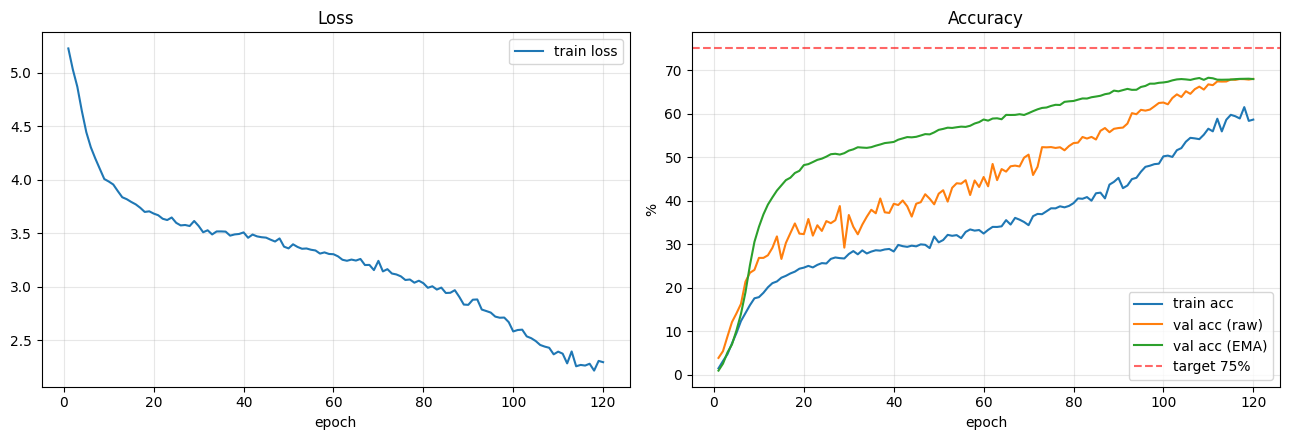

Saved learning_curve.png


In [10]:
# === Learning curves ===
ep = range(1, len(hist['train_acc']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, hist['train_loss'], label='train loss')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, hist['train_acc'], label='train acc')
ax[1].plot(ep, hist['val_acc'],   label='val acc (raw)')
ax[1].plot(ep, hist['val_acc_ema'],label='val acc (EMA)')
ax[1].axhline(75, ls='--', c='r', alpha=.6, label='target 75%')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('%'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('learning_curve.png', dpi=120); plt.show()
print('Saved learning_curve.png')

In [11]:
# === Export to TorchScript (with baked horizontal-flip TTA) + local validation ===
# Flip-TTA averages logits of the image and its horizontal mirror inside the
# module -> still a single TorchScript module, no external calls, same #params.
class TTAWrapper(nn.Module):
    def __init__(self, net, use_tta=True):
        super().__init__()
        self.net = net; self.use_tta = use_tta
    def forward(self, x):
        out = self.net(x)
        if self.use_tta:
            out = out + self.net(torch.flip(x, dims=[3]))
            out = out * 0.5
        return out

best = SEResNetTiny(CFG['num_classes'])
best.load_state_dict(torch.load(CFG['ckpt'], map_location='cpu'))
export_model = TTAWrapper(best, use_tta=True).eval()

dummy = torch.randn(1, 3, 64, 64)
traced = torch.jit.trace(export_model, dummy)
torch.jit.save(traced, CFG['out_pt'])
print('Saved', CFG['out_pt'])

# --- official-style local sanity check ---
m = torch.jit.load(CFG['out_pt'], map_location='cpu').eval()
params = sum(p.numel() for p in m.parameters())
assert params <= 5_000_000, f'Too many params: {params:,}'
with torch.no_grad():
    out = m(torch.randn(1, 3, 64, 64))
assert out.shape == (1, 200), f'Bad output shape: {out.shape}'
print(f'OK - {params:,} params, output {tuple(out.shape)}')

# (optional) copy artifacts to Drive
# !cp final_model.pt learning_curve.png best_ema.pth /content/drive/MyDrive/

Saved final_model.pt
OK - 4,609,544 params, output (1, 200)


## Notes
- **Target 75%** is aggressive for from-scratch Tiny-ImageNet under 5M params. This pipeline (SE-ResNet + RandAugment + MixUp/CutMix + RandomErasing + label smoothing + EMA + flip-TTA) is built to maximize accuracy; expect roughly **66-72%** public-val after 120 epochs, with headroom from longer training (150-200 ep), tuned `base_lr`, or wider channels.
- To push higher: increase `epochs`, raise `base_lr` to 0.15-0.2, or train two seeds and average their logits inside a single `TTAWrapper`-style module (compliant ensembling).
- Submit `final_model.pt` + this notebook (source code). Param count and I/O shape are verified in the last cell.